In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')

In [2]:
class EvaluationState(BaseModel):
    feedback: str = Field(description="detailed feedback for the essay")
    score: float = Field(description="Score out of 10", ge=0, le=10)


In [3]:
essay = """
Only a few years ago, most of us had never interacted with an AI system directly. Then, almost overnight, we began carrying access to reasoning engines in our pockets. Between late 2022 and now, large-language and multimodal models from OpenAI, Anthropic, Google, Meta, and Mistral have evolved from experimental chatbots into broadly capable partners that we can work with to draft policy memos, interpret images, write and troubleshoot code, design molecules, and reason across domains. Every week brings new demonstrations that stretch what we think intelligence is and what we believe these systems can actually do. The shock isn’t just how powerful these systems have become; it’s how quickly they’ve redrawn the boundary between human and machine thought.
As compute and artificial intelligence capabilities grow exponentially, so does the terrain of what can be represented, modeled, or optimized. The expansion of computation makes another kind of intelligence visible in a new way; that is, intuition, or a mode of knowing that synthesizes pattern, context, and feel before it can be spelled out in code or words. It is not knowledge of facts so much as sensitivity to structure in the way recognition precedes explanation. Philosopher-scientist Michael Polanyi called this tacit knowledge, the background sense through which deliberate thought takes shape (The Tacit Dimension, 1966), and Daniel Kahneman later described it as System 1 thinking—fast, associative, and experience-based (Thinking Fast and Slow, 2011). Cognitive scientists Hugo Mercier and Dan Sperber argue in The Enigma of Reason (2017) that reasoning evolved to make intuition shareable to test, refine, and exchange those inarticulate hunches within a community. Intuition and reasoning develop in tandem, each extending the reach of the other.
"""

In [4]:
str_model = model.with_structured_output(EvaluationState)

In [5]:
prompt = f"evaluate the language quality if the following essay and score it out of 10, input:{essay}"
str_model.invoke(prompt).score

8.0

In [6]:
str_model.invoke(prompt).feedback

'The essay exhibits strong language quality with a sophisticated vocabulary and well-structured sentences. The author effectively communicates complex ideas related to AI and cognition. The use of references to notable thinkers and their works lends credibility and depth to the argument, supporting the exploration of intuition in relation to artificial intelligence. There are minimal grammatical errors, and the transitions between ideas are smooth, making the text coherent and engaging. However, some sections may come off as overly dense or complex for a general audience, potentially hindering accessibility. Streamlining certain sentences for clarity could enhance reader comprehension.'

In [7]:
class UPSCState(TypedDict):
    essay: str
    lang_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_Score: Annotated[list[int], operator.add]
    avg_Score:float


In [8]:
def eval_lang(state: UPSCState)-> UPSCState:
    prompt = f"evaluate the language quality if the following essay and score it out of 10, input:{state['essay']}"
    op = str_model.invoke(prompt)
    return {'lang_feedback':op.feedback, 'individual_Score':[op.score]}

def eval_analysis(state: UPSCState)-> UPSCState:
    prompt = f"evaluate the depth of analysis of the following essay and score it out of 10, input:{state['essay']}"
    op = str_model.invoke(prompt)
    return {'analysis_feedback':op.feedback, 'individual_Score':[op.score]}

def eval_clarity(state: UPSCState)-> UPSCState:
    prompt = f"evaluate the clarity of thought of the following essay and score it out of 10, input:{state['essay']}"
    op = str_model.invoke(prompt)
    return {'clarity_feedback':op.feedback, 'individual_Score':[op.score]}


def eval_overall(state: UPSCState)-> UPSCState:
    #summary feedback
    pmpt = f"based on the following feedback create a summarize feedback: language feedback {state['lang_feedback']}, analysis feedback {state['analysis_feedback']}, clarity feedback {state['clarity_feedback']}"
    overall = model.invoke(pmpt).content

    #avg score
    src = sum(state['individual_Score'])/len(state['individual_Score'])

    return {'overall_feedback': overall, 'avg_Score':src}


In [9]:
graph = StateGraph(UPSCState)

graph.add_node('eval_lang',eval_lang)
graph.add_node('eval_analysis',eval_analysis)
graph.add_node('eval_clarity',eval_clarity)
graph.add_node('eval_overall',eval_overall)

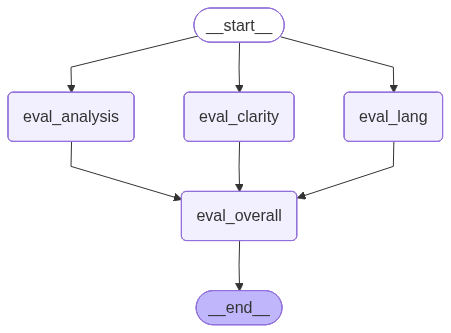

In [10]:
graph.add_edge(START, 'eval_lang')
graph.add_edge(START, 'eval_analysis')
graph.add_edge(START, 'eval_clarity')

graph.add_edge('eval_lang','eval_overall')
graph.add_edge('eval_analysis', 'eval_overall')
graph.add_edge('eval_clarity','eval_overall')

graph.add_edge('eval_overall', END)

wfs = graph.compile()
wfs

In [11]:
init = {
    'essay':essay
}
final = wfs.invoke(init)
final

{'essay': '\nOnly a few years ago, most of us had never interacted with an AI system directly. Then, almost overnight, we began carrying access to reasoning engines in our pockets. Between late 2022 and now, large-language and multimodal models from OpenAI, Anthropic, Google, Meta, and Mistral have evolved from experimental chatbots into broadly capable partners that we can work with to draft policy memos, interpret images, write and troubleshoot code, design molecules, and reason across domains. Every week brings new demonstrations that stretch what we think intelligence is and what we believe these systems can actually do. The shock isn’t just how powerful these systems have become; it’s how quickly they’ve redrawn the boundary between human and machine thought.\nAs compute and artificial intelligence capabilities grow exponentially, so does the terrain of what can be represented, modeled, or optimized. The expansion of computation makes another kind of intelligence visible in a new 